In [3]:
import pandas as pd
import pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("../data/processed/cleaned_walmart.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,3,2010


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
 8   Month         6435 non-null   int64  
 9   Year          6435 non-null   int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 502.9 KB


In [6]:
X = df[['Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Month',
        'Year']]

y = df['Weekly_Sales']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [8]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[1155594.2881536  1103241.56203002 1319899.80163846 1188993.43087315
  700713.49529118]


In [10]:

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)


print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 432293.58773906593
RMSE: 521321.81390435353
R2 Score: 0.15637875886838415


In [11]:
pickle.dump(model, open("sales_model.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


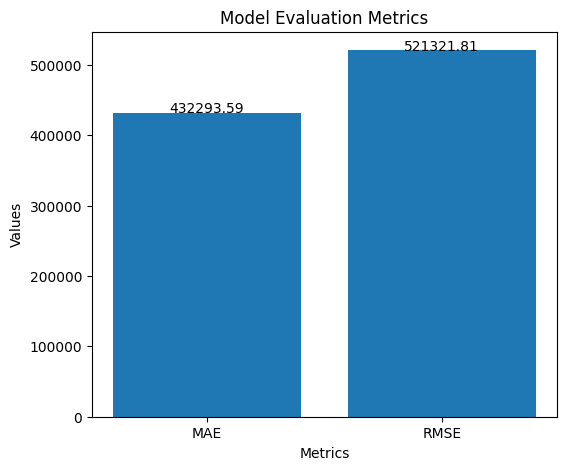

In [12]:
import matplotlib.pyplot as plt



metrics = ["MAE", "RMSE"]



values = [mae, rmse]



plt.figure(figsize=(6, 5))

plt.bar(metrics, values)



plt.title("Model Evaluation Metrics")

plt.xlabel("Metrics")

plt.ylabel("Values")



for i, value in enumerate(values):

    plt.text(
        i,
        value,
        round(value, 2),
        ha='center'
    )


plt.show()

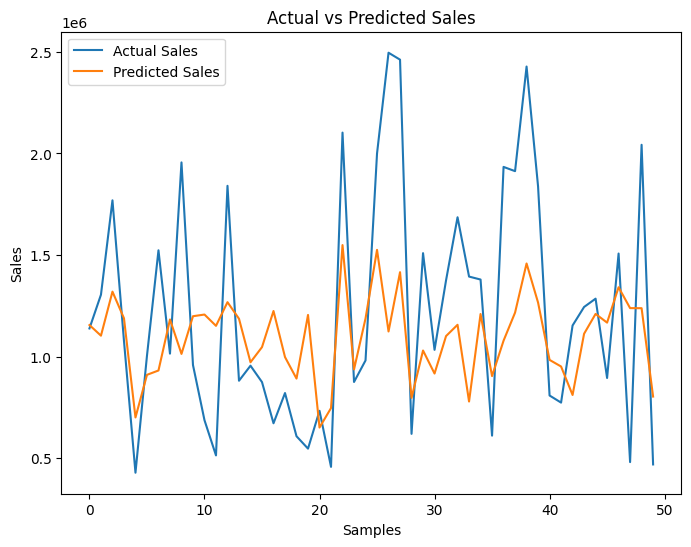

In [13]:
plt.figure(figsize=(8, 6))

plt.plot(
    y_test.values[:50],
    label="Actual Sales"
)

plt.plot(
    y_pred[:50],
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Samples")

plt.ylabel("Sales")

plt.legend()

plt.show()